# =====================================================
# GLOBAL VENTURE CAPITAL & STARTUP ECOSYSTEM ANALYTICS
# =====================================================

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df = pd.read_csv("investments_VC.csv", encoding="latin1")

In [5]:
df.tail()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Remove leading and trailing spaces from all column names
df.columns = df.columns.str.strip()

In [6]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")


Number of Rows    : 54294
Number of Columns : 39


In [7]:
df.columns

Index(['permalink', 'name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [9]:
df.describe()

,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,38482.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,...,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,2007.359129,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,1.628453e+05,...,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,7.579203,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,5.612088e+06,...,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,1902.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,2006.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,7.505000e+08,...,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


In [10]:
df.describe(include='object')

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,founded_at,founded_month,founded_quarter,first_funding_at,last_funding_at
count,49438,49437,45989,45477,45470,49438,48124,44165,30161,44165,43322,38554,38482,38482,49438,49438
unique,49436,49350,45850,16675,753,14617,3,115,61,1089,4188,3369,420,218,3914,3657
top,/organization/treasure-valley-urology-services,Roost,http://spaceport.io,|Software|,Software,-,operating,USA,CA,SF Bay Area,San Francisco,2012-01-01,2012-01,2012-Q1,2012-01-01,2013-01-01
freq,2,4,2,3650,4620,8531,41829,28793,9917,6804,2615,2181,2327,2904,468,387


In [11]:
# Count missing values in each column

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

state_code              24133
founded_month           15812
founded_year            15812
founded_quarter         15812
founded_at              15740
city                    10972
country_code            10129
region                  10129
 market                  8824
category_list            8817
homepage_url             8305
status                   6170
name                     4857
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B                  4856
permalink                4856
round_C                  4856
round_D                  4856
round_E                  4856
private_equity           4856
round_F                  4856
round_G                  4856
post_ipo_equity          4856
venture                  4856
grant                    4856
angel                    4856
debt_financing           4856
convertible_note         4856
undisclosed              4856
equity_crowdfunding      4856
seed      

In [12]:
# Percentage of missing values

missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

state_code              44.448742
founded_month           29.122923
founded_year            29.122923
founded_quarter         29.122923
founded_at              28.990312
city                    20.208494
country_code            18.655837
region                  18.655837
 market                 16.252256
category_list           16.239363
homepage_url            15.296350
status                  11.364055
name                     8.945740
post_ipo_debt            8.943898
secondary_market         8.943898
product_crowdfunding     8.943898
round_A                  8.943898
round_B                  8.943898
permalink                8.943898
round_C                  8.943898
round_D                  8.943898
round_E                  8.943898
private_equity           8.943898
round_F                  8.943898
round_G                  8.943898
post_ipo_equity          8.943898
venture                  8.943898
grant                    8.943898
angel                    8.943898
debt_financing

In [13]:
# Count duplicate rows

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows :", duplicates)

Number of Duplicate Rows : 4855


In [14]:
# Display data types of each column

df.dtypes

permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_crowdfunding    float64
round_A 

In [15]:
# Count unique values in every column

df.nunique().sort_values(ascending=False)

permalink               49436
name                    49350
homepage_url            45850
category_list           16675
 funding_total_usd      14617
venture                  9300
city                     4188
first_funding_at         3914
last_funding_at          3657
founded_at               3369
seed                     3337
round_A                  2035
debt_financing           1872
round_B                  1269
region                   1089
angel                     999
private_equity            847
 market                   753
round_C                   740
undisclosed               687
grant                     532
round_D                   458
founded_month             420
convertible_note          299
equity_crowdfunding       252
post_ipo_equity           239
round_E                   225
founded_quarter           218
product_crowdfunding      176
country_code              115
round_F                   110
founded_year              103
state_code                 61
post_ipo_d

In [16]:
# Display random records from the dataset

df.sample(10, random_state=42)

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
30166,/organization/omaze,Omaze,http://www.omaze.com,|Curated Web|,Curated Web,"10,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12481,/organization/dvdplay,DVDPlay,http://www.dvdplay.com,|Automated Kiosk|Manufacturing|Entertainment|,Entertainment,"2,00,00,000",operating,USA,CA,SF Bay Area,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45753,/organization/veracyte,Veracyte,http://www.veracyte.com,|Health Care|Biotechnology|,Health Care,"7,09,50,000",operating,USA,CA,SF Bay Area,...,0.0,0.0,0.0,28000000.0,28000000.0,0.0,0.0,0.0,0.0,0.0
25853,/organization/medgenics,Medgenics,http://www.medgenics.com,|Biotechnology|,Biotechnology,"3,52,26,066",operating,USA,CA,SF Bay Area,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9194,/organization/cognitive-match,Cognitive Match,http://www.cognitivematch.com,|Personalization|Advertising|,Advertising,"1,01,50,000",acquired,USA,NY,New York City,...,0.0,0.0,1650000.0,2500000.0,6000000.0,0.0,0.0,0.0,0.0,0.0
3154,/organization/are-telecom-wind,ARE Telecom & Wind,http://www.AREtelecom.com,|Networking|,Networking,"1,00,000",operating,USA,MN,Minneapolis,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44849,/organization/ugift,uGift,http://www.ugift.com.ua,|E-Commerce|,E-Commerce,"1,30,000",operating,UKR,NaN,Kiev,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10958,/organization/daric,Daric,http://Daric.com,|Analytics|,Analytics,-,operating,USA,CA,SF Bay Area,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18111,/organization/gruburg,Gruburg,http://www.gruburg.com,|Startups|Reviews and Recommendations|Hospital...,Hospitality,"3,500",closed,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45195,/organization/uptivity-inc,"Uptivity, Inc.",http://www.uptivity.com,|Software|,Software,"65,00,000",acquired,USA,OH,"Columbus, Ohio",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Display memory usage of the dataset

memory = df.memory_usage(deep=True)

memory

Index                       132
permalink               3869736
name                    3179355
homepage_url            3605295
category_list           3759529
 market                 3110481
 funding_total_usd      3066244
status                  2977131
country_code            2620708
state_code              2310467
region                  2899527
city                    2863666
funding_rounds           434352
founded_at              2778366
founded_month           2660976
founded_quarter         2660976
founded_year             434352
first_funding_at        3072234
last_funding_at         3072234
seed                     434352
venture                  434352
equity_crowdfunding      434352
undisclosed              434352
convertible_note         434352
debt_financing           434352
angel                    434352
grant                    434352
private_equity           434352
post_ipo_equity          434352
post_ipo_debt            434352
secondary_market         434352
product_

In [18]:
# Total memory used by the dataset

total_memory = df.memory_usage(deep=True).sum() / 1024**2

print(f"Total Memory Used : {total_memory:.2f} MB")

Total Memory Used : 55.79 MB


In [19]:
# Display all funding related columns

funding_columns = [column for column in df.columns if "fund" in column.lower()]

print(funding_columns)

[' funding_total_usd ', 'funding_rounds', 'first_funding_at', 'last_funding_at', 'equity_crowdfunding', 'product_crowdfunding']


In [20]:
# Display all date related columns

date_columns = [column for column in df.columns if "date" in column.lower() or "year" in column.lower()]

print(date_columns)

['founded_year']


In [21]:
# Display top 10 countries by number of startups

df["country_code"].value_counts().head(10)

country_code
USA    28793
GBR     2642
CAN     1405
CHN     1239
DEU      968
FRA      866
IND      849
ISR      682
ESP      549
RUS      368
Name: count, dtype: int64

In [22]:
# Display startup status distribution

df["status"].value_counts()

status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64

In [24]:
df.columns.tolist()

['permalink',
 'name',
 'homepage_url',
 'category_list',
 ' market ',
 ' funding_total_usd ',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

In [26]:
df.columns.tolist()

['permalink',
 'name',
 'homepage_url',
 'category_list',
 'market',
 'funding_total_usd',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

In [27]:
df["market"].value_counts().head(10)

market
Software                4620
Biotechnology           3688
Mobile                  1983
E-Commerce              1805
Curated Web             1655
Enterprise Software     1280
Health Care             1207
Clean Technology        1200
Games                   1182
Hardware + Software     1081
Name: count, dtype: int64

# ==========================================================
# SECTION 4 : DATA CLEANING
# ==========================================================

# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

In [28]:
# Check duplicate rows
print("Duplicate Rows Before:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 4855
Duplicate Rows After: 0


In [29]:
# Convert funding amount to numeric
df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

In [30]:
df["funding_total_usd"].dtype

dtype('float64')

In [31]:
# Convert date columns into datetime format

date_columns = [
    "founded_at",
    "first_funding_at",
    "last_funding_at"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

In [32]:
df[date_columns].head()

,founded_at,first_funding_at,last_funding_at
0,2012-06-01,2012-06-30,2012-06-30
1,NaT,2010-06-04,2010-09-23
2,2012-10-26,2012-08-09,2012-08-09
3,2011-04-01,2011-04-01,2011-04-01
4,2014-01-01,2014-08-17,2014-09-26


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49439 entries, 0 to 49438
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   permalink             49438 non-null  object        
 1   name                  49437 non-null  object        
 2   homepage_url          45989 non-null  object        
 3   category_list         45477 non-null  object        
 4   market                45470 non-null  object        
 5   funding_total_usd     42 non-null     float64       
 6   status                48124 non-null  object        
 7   country_code          44165 non-null  object        
 8   state_code            30161 non-null  object        
 9   region                44165 non-null  object        
 10  city                  43322 non-null  object        
 11  funding_rounds        49438 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month        

In [34]:
# Calculate startup age

current_year = pd.Timestamp.now().year

df["startup_age"] = current_year - df["founded_year"]

In [35]:
df[["name","founded_year","startup_age"]].head()

,name,founded_year,startup_age
0,#waywire,2012.0,14.0
1,&TV Communications,NaN,NaN
2,'Rock' Your Paper,2012.0,14.0
3,(In)Touch Network,2011.0,15.0
4,-R- Ranch and Mine,2014.0,12.0


In [36]:
df["funding_duration_days"] = (
    df["last_funding_at"] -
    df["first_funding_at"]
).dt.days

In [37]:
df[["name","funding_duration_days"]].head()

,name,funding_duration_days
0,#waywire,0.0
1,&TV Communications,111.0
2,'Rock' Your Paper,0.0
3,(In)Touch Network,0.0
4,-R- Ranch and Mine,40.0


In [38]:
df = df.dropna(subset=["country_code"])

In [39]:
df = df.dropna(subset=["funding_total_usd"])

In [40]:
missing_values = df.isnull().sum()

missing_values[missing_values>0].sort_values(ascending=False)

homepage_url       8
category_list      6
market             6
state_code         6
status             1
founded_at         1
founded_month      1
founded_quarter    1
founded_year       1
startup_age        1
dtype: int64

In [41]:
print("Final Dataset Shape")

print(df.shape)

Final Dataset Shape
(34, 41)


In [42]:
df.to_csv("investments_VC_cleaned.csv",index=False)

# ==========================================================
# SECTION 5 : EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

# Question 1

## Which countries have built the strongest startup ecosystems when considering both startup volume and venture capital investment?

### Objective
The objective of this analysis is to identify countries that have developed strong startup ecosystems by considering both the number of startups and the total venture capital funding received. Rather than simply counting startups, this analysis evaluates whether countries with larger startup ecosystems also attract greater investment.

### Variables Used
- Country (`country_code`)
- Funding Amount (`funding_total_usd`)
- Startup Name (`name`)

### Why This Analysis?
A country with many startups does not necessarily attract the highest investment. Comparing startup volume with total funding provides a more comprehensive understanding of ecosystem strength and investment concentration.

In [51]:
# Top startup ecosystems based on startup count and funding

country_analysis = (
    df.groupby("country_code")
      .agg(
          Startup_Count=("name", "count"),
          Total_Funding=("funding_total_usd", "sum"),
          Average_Funding=("funding_total_usd", "mean")
      )
      .reset_index()
)

# Keep only the top 15 countries by startup count
country_analysis = (
    country_analysis
    .sort_values(by="Startup_Count", ascending=False)
    .head(15)
)

country_analysis

,country_code,Startup_Count,Total_Funding,Average_Funding
6,USA,28,10097.0,360.607143
0,DEU,1,60.0,60.000000
1,GBR,1,100.0,100.000000
2,JOR,1,14.0,14.000000
3,KOR,1,102.0,102.000000
4,ROM,1,600.0,600.000000
5,SWE,1,215.0,215.000000


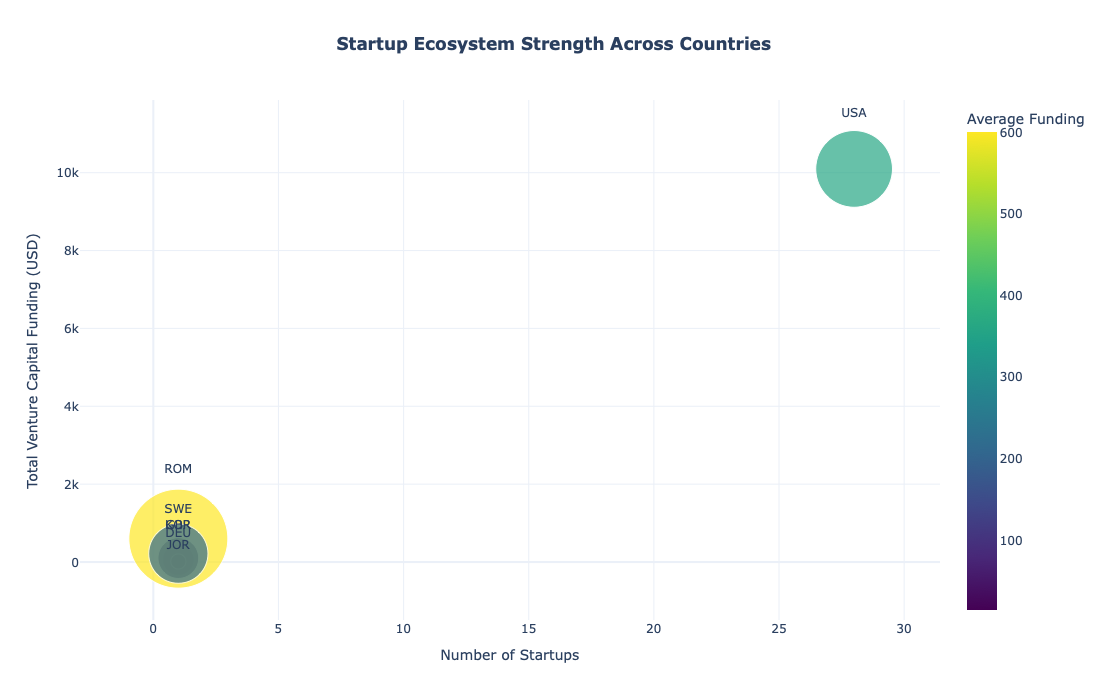

In [52]:
import plotly.express as px

fig = px.scatter(
    country_analysis,
    x="Startup_Count",
    y="Total_Funding",
    size="Average_Funding",
    color="Average_Funding",
    hover_name="country_code",
    text="country_code",
    size_max=70,
    color_continuous_scale="Viridis",
    title="<b>Startup Ecosystem Strength Across Countries</b>"
)

fig.update_traces(textposition="top center")

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700,
    xaxis_title="Number of Startups",
    yaxis_title="Total Venture Capital Funding (USD)",
    coloraxis_colorbar_title="Average Funding"
)

fig.show()

### Key Insight

This analysis compares startup ecosystems by simultaneously considering startup volume and total venture capital investment. Countries located in the upper-right region of the chart combine a large number of startups with substantial funding, indicating mature entrepreneurial ecosystems. Bubble size and colour represent the average funding per startup, allowing the identification of countries that attract higher investment despite having relatively fewer startups.

This multidimensional approach provides a more meaningful assessment of ecosystem strength than startup counts alone.

# Question 2

## Which startup industries attract the highest venture capital investment relative to the number of startups?

### Objective
The objective of this analysis is to identify industries that receive disproportionately high venture capital funding compared to the number of startups operating within them. This helps distinguish capital-intensive industries from industries with many startups but relatively lower investment.

### Variables Used
- Market (`market`)
- Funding Amount (`funding_total_usd`)
- Startup Name (`name`)

### Why This Analysis?
A large number of startups does not necessarily imply greater investment. Some industries attract significantly more capital despite having relatively few startups. Understanding this relationship helps investors identify industries with higher capital intensity and investment concentration.

In [53]:
# Analyse startup industries

market_analysis = (
    df.groupby("market")
      .agg(
          Startup_Count=("name", "count"),
          Total_Funding=("funding_total_usd", "sum"),
          Average_Funding=("funding_total_usd", "mean")
      )
      .reset_index()
)

# Remove missing markets
market_analysis = market_analysis.dropna()

# Select top 15 industries by total funding
market_analysis = (
    market_analysis
    .sort_values(by="Total_Funding", ascending=False)
    .head(15)
)

market_analysis

,market,Startup_Count,Total_Funding,Average_Funding
9,Medical,4,1800.0,450.000000
1,Consulting,4,1600.0,400.000000
3,Entertainment,2,1117.0,558.500000
2,E-Commerce,1,800.0,800.000000
6,Games,2,600.0,300.000000
12,Software,2,590.0,295.000000
0,Automotive,1,500.0,500.000000
7,Hospitality,1,500.0,500.000000
5,Fashion,3,410.0,136.666667
13,Sports,1,400.0,400.000000


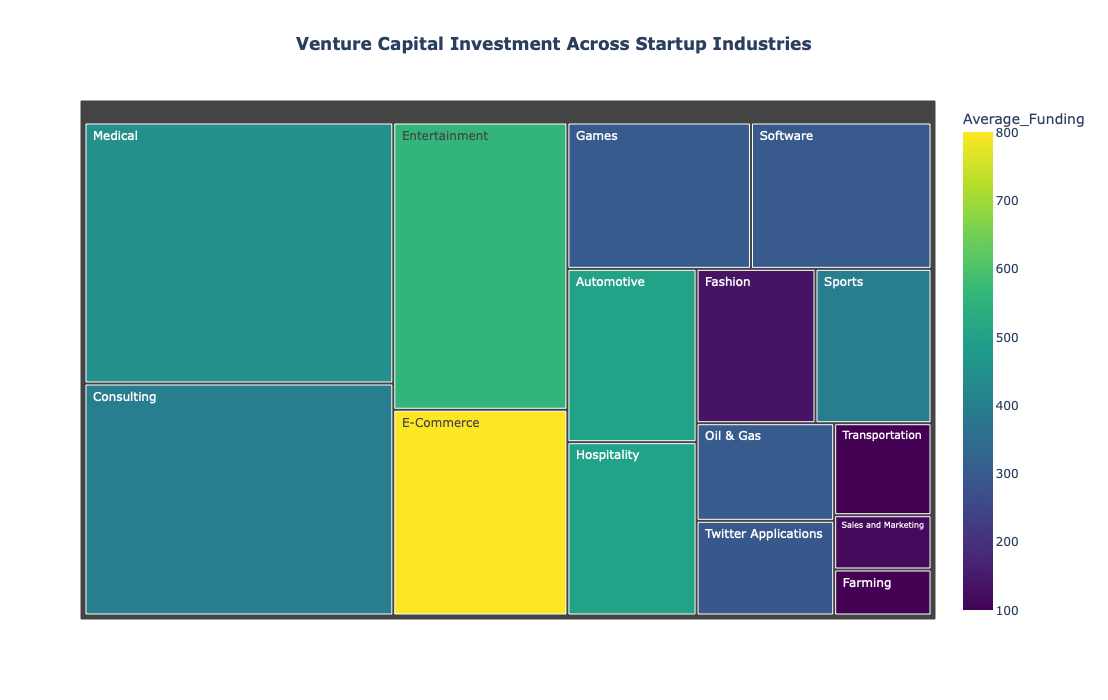

In [54]:
import plotly.express as px

fig = px.treemap(
    market_analysis,
    path=["market"],
    values="Total_Funding",
    color="Average_Funding",
    color_continuous_scale="Viridis",
    hover_data={
        "Startup_Count": True,
        "Average_Funding": ":,.0f",
        "Total_Funding": ":,.0f"
    },
    title="<b>Venture Capital Investment Across Startup Industries</b>"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700
)

fig.show()

### Key Insight

The treemap illustrates how venture capital investment is distributed across major startup industries. The size of each rectangle represents the total funding received by an industry, while the colour indicates the average funding per startup.

Industries occupying large areas but containing relatively fewer startups demonstrate high capital intensity, whereas industries with many startups but smaller funding allocations suggest lower investment per company. This analysis enables investors to identify sectors that require substantial financial commitment and exhibit stronger investment concentration.

# Question 3

## Does the age of a startup influence the amount of venture capital it receives, and does this relationship differ by startup status?

### Objective
The objective of this analysis is to examine whether older startups tend to receive greater venture capital funding compared to younger startups. Additionally, the analysis investigates whether this relationship varies according to the startup's current business status (Operating, Acquired, IPO, or Closed).

### Variables Used
- Startup Age (`startup_age`)
- Funding Amount (`funding_total_usd`)
- Startup Status (`status`)

### Why This Analysis?
Startup age is often associated with business maturity and investor confidence. However, younger startups with disruptive business models may also attract substantial investment. By incorporating startup status into the analysis, we can better understand how maturity and business outcomes relate to venture capital funding.

In [55]:
# Select required columns

startup_age_df = df[
    ["startup_age", "funding_total_usd", "status", "name"]
].copy()

# Remove missing values
startup_age_df.dropna(inplace=True)

# Remove unrealistic ages
startup_age_df = startup_age_df[
    (startup_age_df["startup_age"] >= 0) &
    (startup_age_df["startup_age"] <= 50)
]

startup_age_df.head()

,startup_age,funding_total_usd,status,name
3313,12.0,100.0,operating,Art of the Dream
4850,12.0,144.0,operating,BESOS
5533,13.0,100.0,operating,Blackbird Holdings
9016,13.0,300.0,operating,Cmilligan Investments
9424,21.0,500.0,operating,Community Baptist Mission


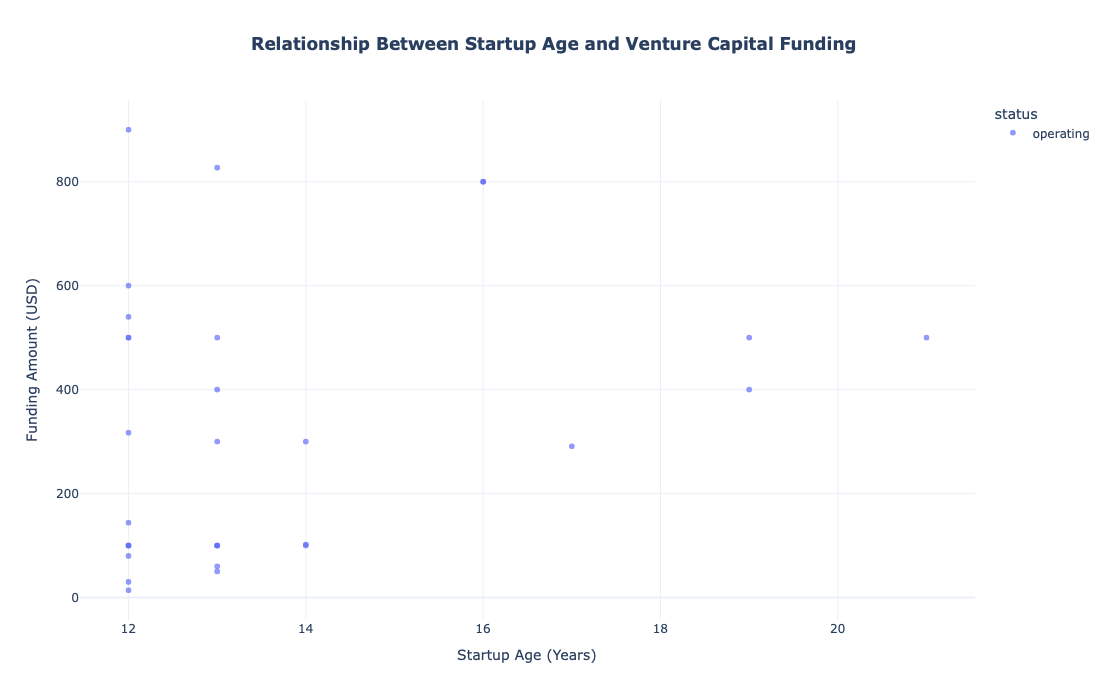

In [56]:
import plotly.express as px

fig = px.scatter(
    startup_age_df,
    x="startup_age",
    y="funding_total_usd",
    color="status",
    hover_name="name",
    opacity=0.7,
    title="<b>Relationship Between Startup Age and Venture Capital Funding</b>",
    labels={
        "startup_age":"Startup Age (Years)",
        "funding_total_usd":"Funding Amount (USD)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700
)

fig.show()

### Key Insight

The scatter plot explores whether startup maturity influences venture capital investment. While older startups often receive larger funding amounts, the presence of highly funded young startups demonstrates that innovation and market potential can outweigh company age.

The colour coding further reveals how startup status influences funding patterns, allowing comparisons between Operating, Acquired, IPO, and Closed companies. This multidimensional analysis provides a deeper understanding of investment behaviour than analysing startup age or funding independently.

# Question 4

## Are startups with more funding rounds more likely to achieve successful business outcomes such as acquisition or IPO?

### Objective
The objective of this analysis is to investigate whether startups that undergo multiple funding rounds are more likely to achieve successful business outcomes, such as being acquired or going public through an Initial Public Offering (IPO).

### Variables Used
- Funding Rounds (`funding_rounds`)
- Funding Amount (`funding_total_usd`)
- Startup Status (`status`)

### Why This Analysis?
Venture capital is typically raised over multiple funding rounds as startups grow. Understanding whether companies with more funding rounds tend to achieve successful exits provides valuable insight into startup growth strategies and investment patterns.

In [59]:
# Select relevant columns

funding_rounds_df = df[
    ["funding_rounds", "funding_total_usd", "status"]
].copy()

# Remove missing values
funding_rounds_df.dropna(inplace=True)

# Remove unrealistic values
funding_rounds_df = funding_rounds_df[
    funding_rounds_df["funding_rounds"] > 0
]

funding_rounds_df.head()

,funding_rounds,funding_total_usd,status
3313,1.0,100.0,operating
4850,1.0,144.0,operating
5533,1.0,100.0,operating
9016,1.0,300.0,operating
9424,1.0,500.0,operating


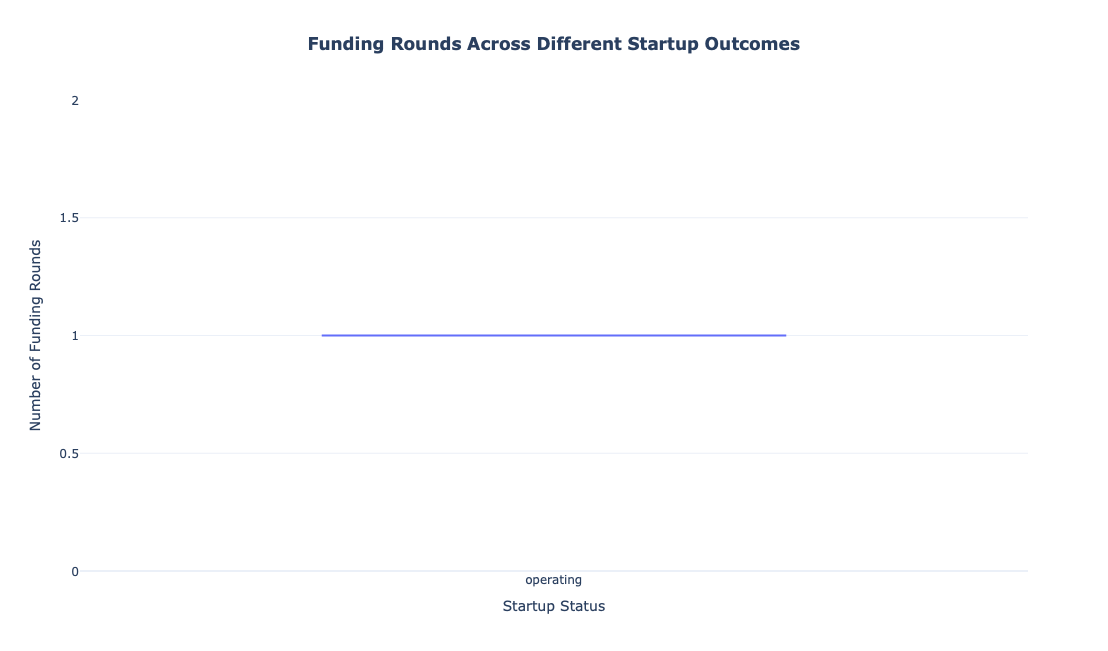

In [60]:
import plotly.express as px

fig = px.box(
    funding_rounds_df,
    x="status",
    y="funding_rounds",
    color="status",
    points="outliers",
    title="<b>Funding Rounds Across Different Startup Outcomes</b>",
    labels={
        "status":"Startup Status",
        "funding_rounds":"Number of Funding Rounds"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=650,
    showlegend=False
)

fig.show()

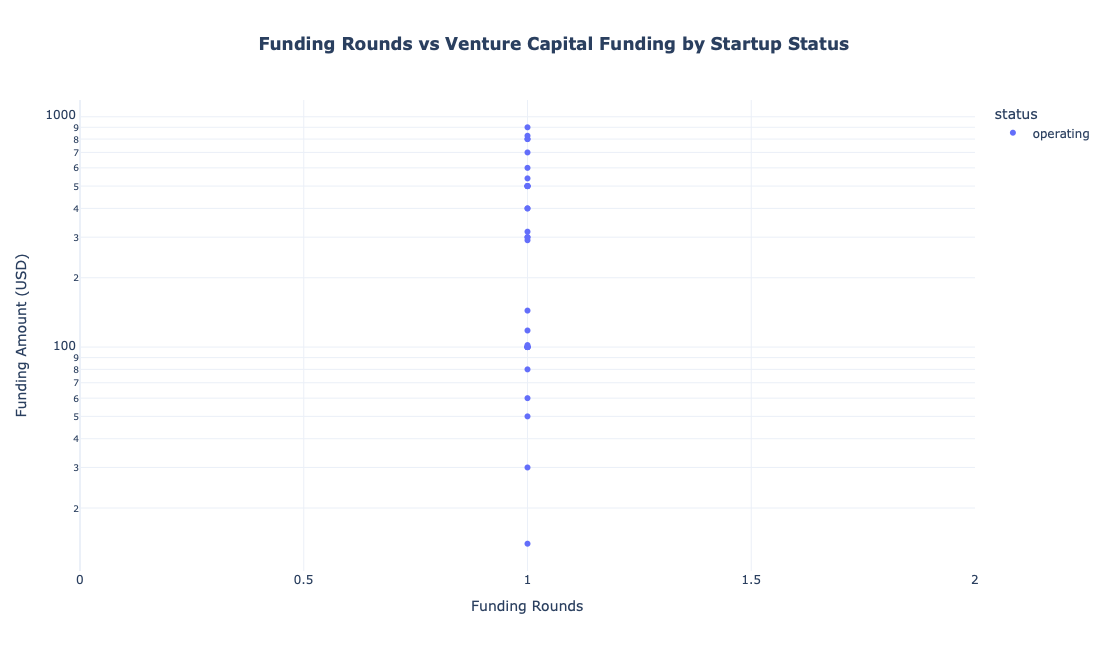

In [61]:
fig = px.scatter(
    funding_rounds_df,
    x="funding_rounds",
    y="funding_total_usd",
    color="status",
    log_y=True,
    title="<b>Funding Rounds vs Venture Capital Funding by Startup Status</b>",
    labels={
        "funding_rounds":"Funding Rounds",
        "funding_total_usd":"Funding Amount (USD)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=650
)

fig.show()

### Key Insight

The analysis compares the number of funding rounds across different startup outcomes. Companies that are acquired or reach an IPO generally participate in multiple funding rounds before achieving a successful exit, reflecting sustained investor confidence and business growth.

However, the presence of outliers indicates that some startups achieve significant success with relatively fewer funding rounds, suggesting that innovation, market demand, and business strategy also play important roles in determining startup success.

# Question 5

## How has venture capital investment evolved over time across different startup industries?

### Objective
The objective of this analysis is to examine how venture capital investment has changed over time across major startup industries. By comparing funding trends across industries, we can identify sectors that have experienced sustained investor interest, rapid growth, or declining investment over the years.

### Variables Used
- First Funding Year (`first_funding_at`)
- Market (`market`)
- Funding Amount (`funding_total_usd`)

### Why This Analysis?
Investment priorities change as technology evolves and market demands shift. Analyzing funding trends over time helps identify industries that have consistently attracted venture capital and those that have emerged as new investment hotspots.

In [63]:
# Extract year from first funding date

trend_df = df[
    ["first_funding_at", "market", "funding_total_usd"]
].copy()

trend_df.dropna(inplace=True)

# Convert to datetime
trend_df["first_funding_at"] = pd.to_datetime(
    trend_df["first_funding_at"],
    errors="coerce"
)

trend_df.dropna(inplace=True)

# Extract funding year
trend_df["Funding_Year"] = trend_df["first_funding_at"].dt.year

# Keep only top 8 industries by total funding
top_markets = (
    trend_df.groupby("market")["funding_total_usd"]
            .sum()
            .nlargest(8)
            .index
)

trend_df = trend_df[
    trend_df["market"].isin(top_markets)
]

trend_df.head()

,first_funding_at,market,funding_total_usd,Funding_Year
3313,2014-05-17,Games,100.0,2014
5533,2014-01-12,Medical,100.0,2014
11921,2014-06-05,Medical,600.0,2014
13242,2013-10-14,Automotive,500.0,2013
17794,2014-07-28,Hospitality,500.0,2014


In [64]:
funding_trend = (
    trend_df.groupby(["Funding_Year", "market"])
            .agg(
                Total_Funding=("funding_total_usd", "sum")
            )
            .reset_index()
)

funding_trend.head()

,Funding_Year,market,Total_Funding
0,2013,Automotive,500.0
1,2013,Consulting,100.0
2,2013,E-Commerce,800.0
3,2013,Games,500.0
4,2013,Software,50.0


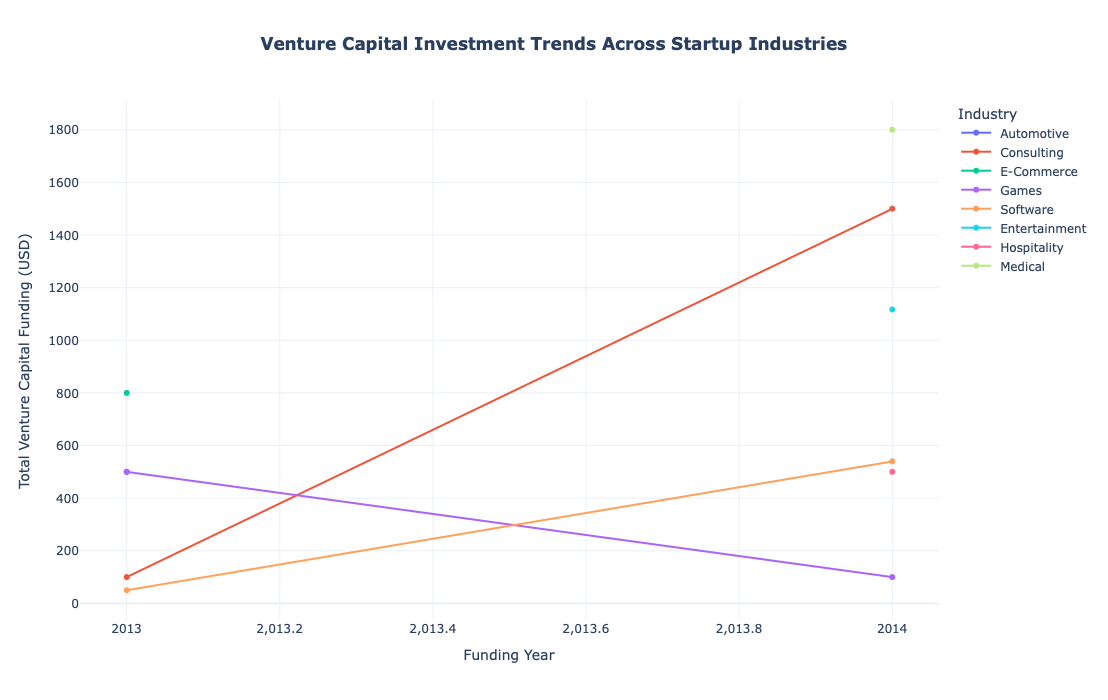

In [65]:
import plotly.express as px

fig = px.line(
    funding_trend,
    x="Funding_Year",
    y="Total_Funding",
    color="market",
    markers=True,
    title="<b>Venture Capital Investment Trends Across Startup Industries</b>",
    labels={
        "Funding_Year": "Funding Year",
        "Total_Funding": "Total Venture Capital Funding (USD)",
        "market": "Industry"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700
)

fig.show()

### Key Insight

The line chart illustrates how venture capital investment has evolved across major startup industries over time. Some industries demonstrate consistent long-term growth in investment, indicating sustained investor confidence, while others experience short periods of rapid funding followed by slower growth.

Comparing multiple industries over time highlights shifts in investor priorities and reveals sectors that have become increasingly attractive for venture capital investment.

# Question 6

## Which countries specialize in particular startup industries, and how does venture capital funding vary across these specializations?

### Objective
The objective of this analysis is to identify the dominant startup industries in different countries and compare the amount of venture capital invested in these industries. This helps reveal how countries develop competitive advantages in specific sectors.

### Variables Used
- Country (`country_code`)
- Market (`market`)
- Funding Amount (`funding_total_usd`)

### Why This Analysis?
Startup ecosystems are often shaped by regional expertise and investment priorities. By comparing industries across countries, we can identify which sectors drive innovation and attract venture capital in different parts of the world.

In [68]:
# Select required columns
country_market_df = df[
    ["country_code", "market", "funding_total_usd"]
].copy()

# Remove missing values
country_market_df.dropna(inplace=True)

# Keep only the top 10 countries by startup count
top_countries = (
    country_market_df["country_code"]
    .value_counts()
    .head(10)
    .index
)

# Keep only the top 10 industries by startup count
top_markets = (
    country_market_df["market"]
    .value_counts()
    .head(10)
    .index
)

country_market_df = country_market_df[
    (country_market_df["country_code"].isin(top_countries)) &
    (country_market_df["market"].isin(top_markets))
]

country_market_df.head()

,country_code,market,funding_total_usd
3313,USA,Games,100.0
5533,USA,Medical,100.0
9016,USA,Oil & Gas,300.0
11921,ROM,Medical,600.0
13242,USA,Automotive,500.0


In [69]:
# Select required columns
country_market_df = df[
    ["country_code", "market", "funding_total_usd"]
].copy()

# Remove missing values
country_market_df.dropna(inplace=True)

# Keep only the top 10 countries by startup count
top_countries = (
    country_market_df["country_code"]
    .value_counts()
    .head(10)
    .index
)

# Keep only the top 10 industries by startup count
top_markets = (
    country_market_df["market"]
    .value_counts()
    .head(10)
    .index
)

country_market_df = country_market_df[
    (country_market_df["country_code"].isin(top_countries)) &
    (country_market_df["market"].isin(top_markets))
]

country_market_df.head()

,country_code,market,funding_total_usd
3313,USA,Games,100.0
5533,USA,Medical,100.0
9016,USA,Oil & Gas,300.0
11921,ROM,Medical,600.0
13242,USA,Automotive,500.0


In [70]:
heatmap_data = (
    country_market_df.groupby(
        ["country_code", "market"]
    )["funding_total_usd"]
    .sum()
    .reset_index()
)

heatmap_data.head()

,country_code,market,funding_total_usd
0,GBR,Consulting,100.0
1,ROM,Medical,600.0
2,USA,Automotive,500.0
3,USA,Consulting,1500.0
4,USA,Entertainment,1117.0


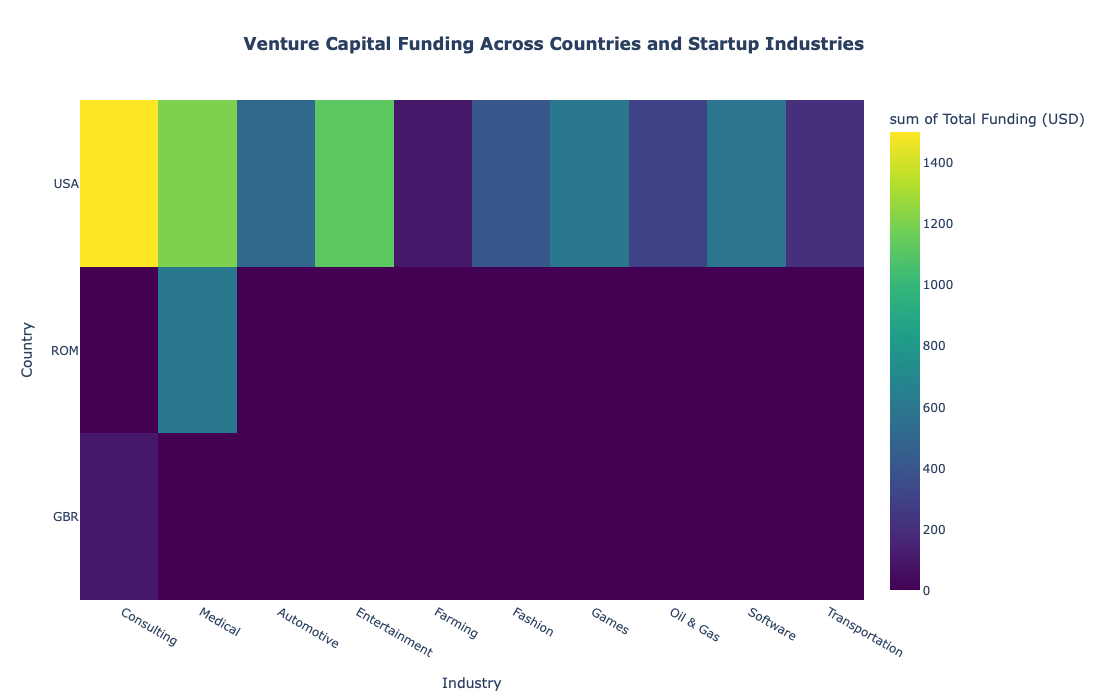

In [71]:
import plotly.express as px

fig = px.density_heatmap(
    heatmap_data,
    x="market",
    y="country_code",
    z="funding_total_usd",
    color_continuous_scale="Viridis",
    title="<b>Venture Capital Funding Across Countries and Startup Industries</b>",
    labels={
        "market": "Industry",
        "country_code": "Country",
        "funding_total_usd": "Total Funding (USD)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700
)

fig.show()

### Key Insight

The heatmap highlights how venture capital investment is distributed across industries in different countries. Darker cells indicate industry-country combinations that attract higher levels of investment, revealing areas of specialization.

The analysis shows that startup ecosystems are not uniform across countries. Some countries attract funding across a wide range of industries, while others exhibit strong specialization in a few sectors. Understanding these patterns provides valuable insight into regional innovation strengths and investment opportunities.

# Question 7

## Which startup industries exhibit the greatest funding inequality?

### Objective
The objective of this analysis is to compare the distribution of venture capital funding across different startup industries. Rather than focusing only on total investment, this analysis examines whether funding is evenly distributed or concentrated among a small number of startups within each industry.

### Variables Used
- Market (`market`)
- Funding Amount (`funding_total_usd`)

### Why This Analysis?
Total funding alone does not indicate how investment is distributed within an industry. Some industries may have a few startups receiving exceptionally large investments, while others distribute funding more evenly. Understanding funding inequality helps identify industries with higher investment concentration and financial risk.

In [75]:
# Select required columns
funding_distribution = df[
    ["market", "funding_total_usd"]
].copy()

# Remove missing values
funding_distribution.dropna(inplace=True)

# Keep only the top 10 industries by startup count
top_markets = (
    funding_distribution["market"]
    .value_counts()
    .head(10)
    .index
)

funding_distribution = funding_distribution[
    funding_distribution["market"].isin(top_markets)
]

funding_distribution.head()

,market,funding_total_usd
3313,Games,100.0
5533,Medical,100.0
9016,Oil & Gas,300.0
11921,Medical,600.0
13242,Automotive,500.0


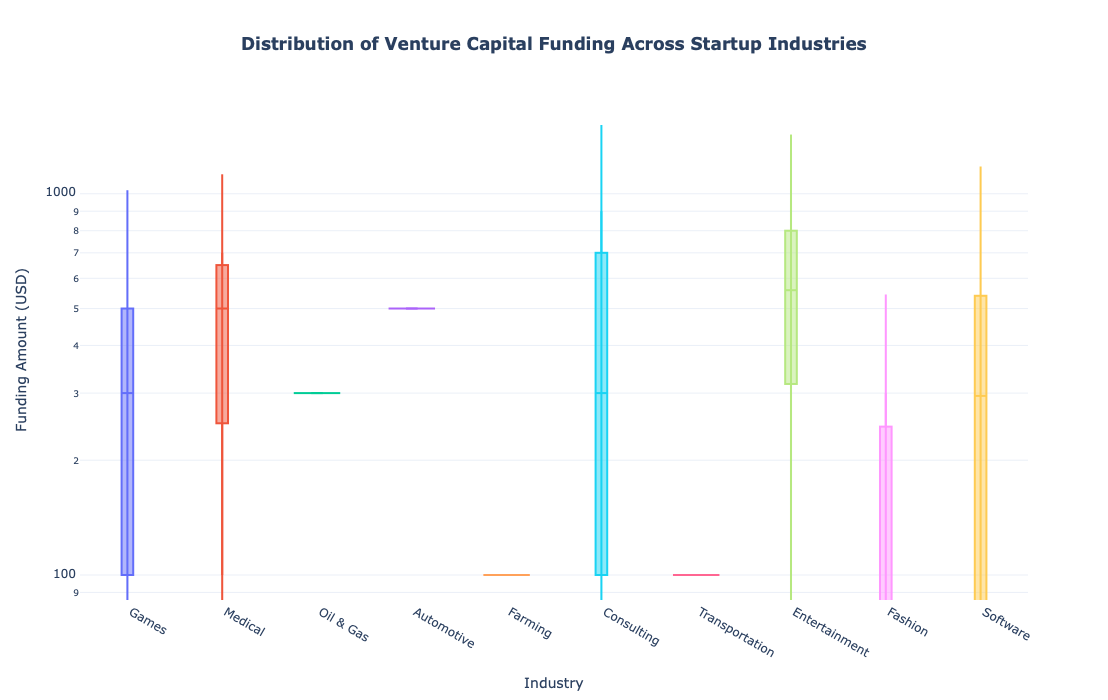

In [76]:
import plotly.express as px

fig = px.violin(
    funding_distribution,
    x="market",
    y="funding_total_usd",
    color="market",
    box=True,
    points="outliers",
    log_y=True,
    title="<b>Distribution of Venture Capital Funding Across Startup Industries</b>"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700,
    xaxis_title="Industry",
    yaxis_title="Funding Amount (USD)",
    showlegend=False
)

fig.show()

### Key Insight

The violin plot illustrates the distribution of venture capital funding across major startup industries. Wider sections of each violin indicate funding levels where many startups are concentrated, while the box plot inside each violin summarizes the median and interquartile range.

Industries with long upper tails and numerous outliers indicate that a small number of startups receive exceptionally high investments, reflecting greater funding inequality. In contrast, industries with narrower distributions suggest that venture capital is allocated more consistently across startups.

# Question 8

## Which regions attract the highest venture capital investment relative to the number of startups?

### Objective
The objective of this analysis is to compare global startup regions by evaluating both the number of startups and the total venture capital investment they receive. This analysis identifies regions that attract significant investment despite having relatively fewer startups.

### Variables Used
- Region (`region`)
- Startup Name (`name`)
- Funding Amount (`funding_total_usd`)

### Why This Analysis?
Some startup regions may host fewer companies while attracting disproportionately high venture capital investment. Comparing startup density with investment provides insights into regional investment efficiency and emerging innovation hubs.

In [78]:
# Regional startup ecosystem analysis

region_analysis = (
    df.groupby("region")
      .agg(
          Startup_Count=("name", "count"),
          Total_Funding=("funding_total_usd", "sum"),
          Average_Funding=("funding_total_usd", "mean")
      )
      .reset_index()
)

# Remove missing regions
region_analysis.dropna(inplace=True)

# Keep top 15 regions by startup count
region_analysis = (
    region_analysis
    .sort_values(by="Startup_Count", ascending=False)
    .head(15)
)

region_analysis.head()

,region,Startup_Count,Total_Funding,Average_Funding
2,Atlanta,2,850.0,425.0
28,South Bend,2,444.0,222.0
22,New York City,2,180.0,90.0
0,Amman,1,14.0,14.0
16,Las Vegas,1,500.0,500.0


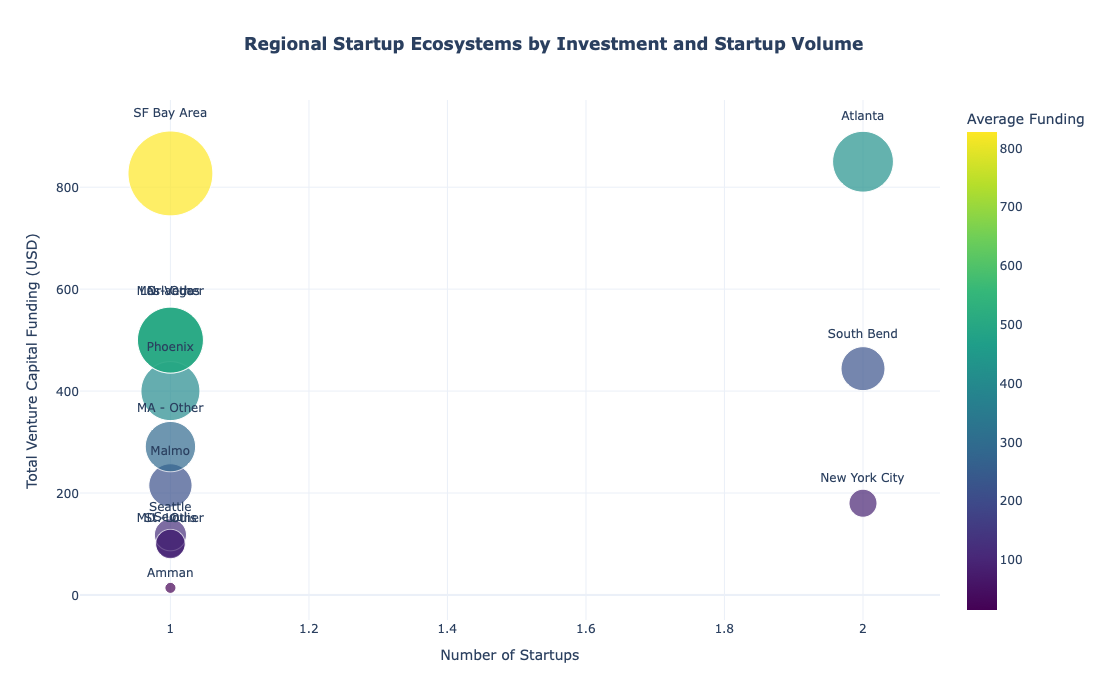

In [79]:
import plotly.express as px

fig = px.scatter(
    region_analysis,
    x="Startup_Count",
    y="Total_Funding",
    size="Average_Funding",
    color="Average_Funding",
    hover_name="region",
    text="region",
    size_max=60,
    color_continuous_scale="Viridis",
    title="<b>Regional Startup Ecosystems by Investment and Startup Volume</b>"
)

fig.update_traces(textposition="top center")

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700,
    xaxis_title="Number of Startups",
    yaxis_title="Total Venture Capital Funding (USD)",
    coloraxis_colorbar_title="Average Funding"
)

fig.show()

### Key Insight

The bubble chart compares startup ecosystems across major regions using startup count, total venture capital funding, and average funding per startup. Regions positioned in the upper-right corner represent mature ecosystems with both high startup activity and strong investment.

Larger bubbles indicate regions where startups receive higher average funding, highlighting areas that may have fewer startups but stronger investment intensity. This analysis helps identify established innovation hubs as well as emerging regions attracting substantial venture capital.

# Question 9

## How is venture capital distributed across startup industries and business outcomes?

### Objective
The objective of this analysis is to examine how venture capital funding is distributed across different startup industries and business outcomes. By combining industry sectors with company status, this analysis provides a comprehensive view of where investment is concentrated and which industries produce more successful startup outcomes.

### Variables Used
- Market (`market`)
- Startup Status (`status`)
- Funding Amount (`funding_total_usd`)

### Why This Analysis?
Different industries experience different business outcomes despite receiving venture capital funding. Understanding how investment is distributed among operating companies, acquisitions, IPOs, and closed businesses helps reveal which industries generate stronger investment returns and more sustainable startup ecosystems.

In [82]:
# Select required columns

sunburst_df = df[
    ["market", "status", "funding_total_usd"]
].copy()

# Remove missing values
sunburst_df.dropna(inplace=True)

# Keep top 10 industries by total funding
top_markets = (
    sunburst_df.groupby("market")["funding_total_usd"]
               .sum()
               .nlargest(10)
               .index
)

sunburst_df = sunburst_df[
    sunburst_df["market"].isin(top_markets)
]

sunburst_df.head()

,market,status,funding_total_usd
3313,Games,operating,100.0
5533,Medical,operating,100.0
11921,Medical,operating,600.0
13242,Automotive,operating,500.0
17794,Hospitality,operating,500.0


In [83]:
sunburst_data = (
    sunburst_df.groupby(
        ["market", "status"]
    )
    .agg(
        Total_Funding=("funding_total_usd", "sum")
    )
    .reset_index()
)

sunburst_data.head()

,market,status,Total_Funding
0,Automotive,operating,500.0
1,Consulting,operating,1600.0
2,E-Commerce,operating,800.0
3,Entertainment,operating,1117.0
4,Fashion,operating,410.0


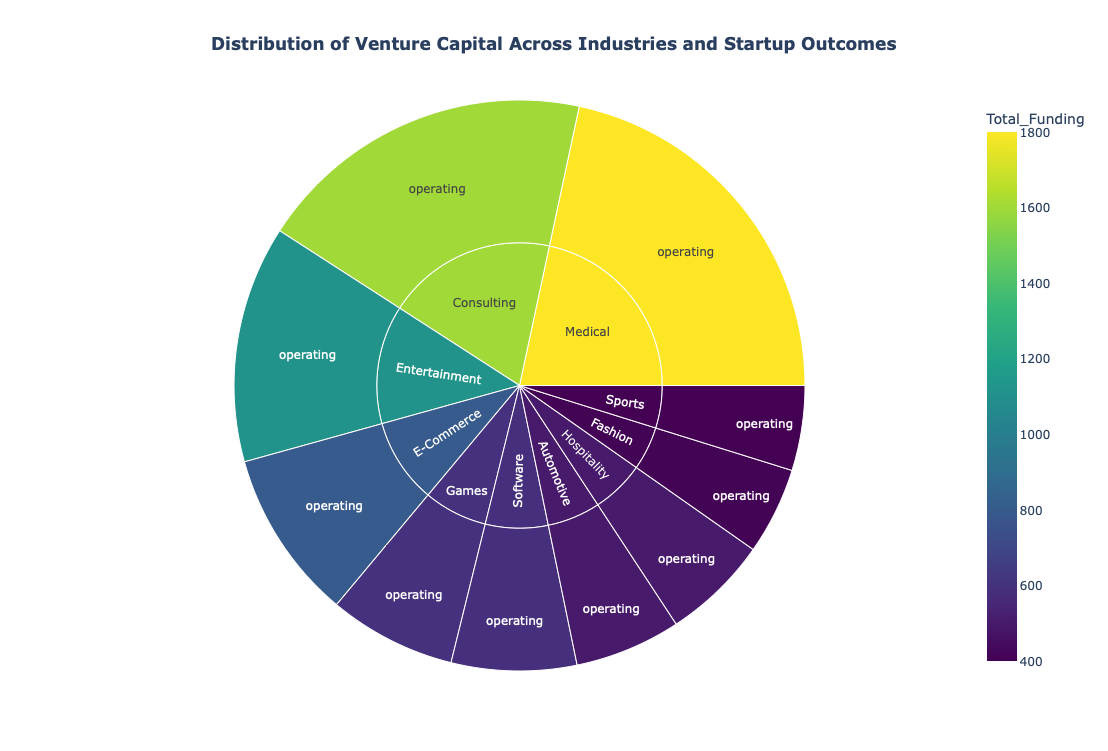

In [84]:
import plotly.express as px

fig = px.sunburst(
    sunburst_data,
    path=["market", "status"],
    values="Total_Funding",
    color="Total_Funding",
    color_continuous_scale="Viridis",
    title="<b>Distribution of Venture Capital Across Industries and Startup Outcomes</b>"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=750
)

fig.show()

### Key Insight

The sunburst chart illustrates how venture capital funding is distributed across major startup industries and their business outcomes. The inner ring represents startup industries, while the outer ring shows the distribution of funding among different company statuses such as Operating, Acquired, IPO, and Closed.

Industries with larger segments allocated to Acquired or IPO companies may indicate stronger commercialization potential and higher investment returns. Conversely, industries dominated by Operating or Closed startups may suggest longer development cycles or greater investment risk.

# Question 10

## Which countries attract the highest average venture capital investment per startup?

### Objective
The objective of this analysis is to compare countries based on the average venture capital funding received per startup. Unlike total funding, this metric highlights investment efficiency by identifying countries where startups attract higher levels of capital on average.

### Variables Used
- Country (`country_code`)
- Funding Amount (`funding_total_usd`)
- Startup Name (`name`)

### Why This Analysis?
Countries with the highest total funding do not necessarily provide the highest investment per startup. Measuring average funding reveals ecosystems where startups receive stronger financial backing, offering insights into investor confidence and capital concentration.'

In [87]:
# Average funding per startup by country

country_avg = (
    df.groupby("country_code")
      .agg(
          Startup_Count=("name", "count"),
          Total_Funding=("funding_total_usd", "sum"),
          Average_Funding=("funding_total_usd", "mean")
      )
      .reset_index()
)

# Remove countries with very few startups (to avoid misleading averages)
country_avg = country_avg[country_avg["Startup_Count"] >= 10]

country_avg.head()

,country_code,Startup_Count,Total_Funding,Average_Funding
6,USA,28,10097.0,360.607143


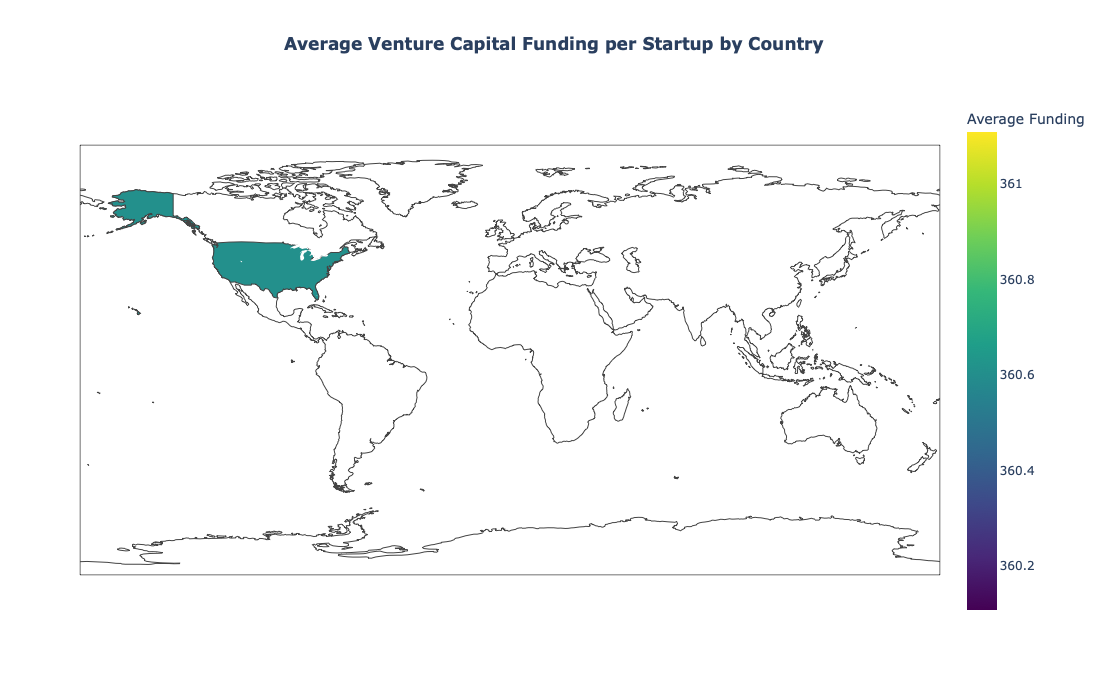

In [88]:
import plotly.express as px

fig = px.choropleth(
    country_avg,
    locations="country_code",
    color="Average_Funding",
    hover_name="country_code",
    hover_data={
        "Startup_Count": True,
        "Total_Funding": ":,.0f",
        "Average_Funding": ":,.0f"
    },
    color_continuous_scale="Viridis",
    title="<b>Average Venture Capital Funding per Startup by Country</b>"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700,
    coloraxis_colorbar_title="Average Funding"
)

fig.show()

### Key Insight

The choropleth map compares countries based on the average venture capital funding received per startup. Unlike total funding, this metric highlights investment efficiency by accounting for the number of startups in each country.

Countries with higher average funding per startup indicate stronger investor confidence and greater capital concentration, whereas countries with many startups but lower average funding may represent highly competitive ecosystems with more distributed investment. This analysis complements the previous country-level findings by providing a more balanced perspective on global startup ecosystems.

# Overall Conclusion

This project analyzed the global venture capital ecosystem using multiple dimensions, including geography, industry, startup maturity, funding strategy, and business outcomes.

The analysis revealed that:
- Venture capital investment is highly concentrated in a small number of countries and regions.
- Certain industries attract substantially higher investment despite having fewer startups, indicating greater capital intensity.
- Startup age alone does not determine funding success, as younger companies can also secure significant investment.
- Companies progressing through multiple funding rounds are generally associated with stronger business outcomes such as acquisitions and IPOs.
- Funding patterns have evolved over time, reflecting changing investor priorities across industries.
- Startup ecosystems exhibit clear regional and industry specializations.
- Venture capital distribution is uneven across industries, with some sectors dominated by a few highly funded companies.
- Average funding per startup varies considerably across countries, highlighting differences in investment efficiency.

Overall, the findings demonstrate that startup success depends on a combination of ecosystem maturity, industry focus, investment strategy, and regional characteristics rather than any single factor.